<a href="https://colab.research.google.com/github/Kishoby/Conceptual-Research_Hybrid-Approach/blob/Humidity/Humidity_XAI_3_Iterations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

!pip install river --quiet

In [2]:
import pandas as pd
import numpy as np

from river import metrics, compose, preprocessing

print("River imported successfully")

River imported successfully


In [3]:

import pandas as pd

path = "/content/drive/MyDrive/Research v2/Research 18.03.2026/Humidity/final_humidity_dataset (1).csv"

humidity_df = pd.read_csv(path)

print("Dataset shape:", humidity_df.shape)
humidity_df.head()

Dataset shape: (130003, 16)


,uv_index,cloud,condition_text,air_quality_Ozone,temperature_celsius,feels_like_celsius,air_quality_us-epa-index,air_quality_gb-defra-index,longitude,precip_mm,air_quality_PM10,air_quality_PM2.5,visibility_km,air_quality_Sulphur_dioxide,latitude,humidity
0,1.0,0,2,62.2,16.1,16.1,1,1,-120.49,0.00,7.1,6.3,16.0,0.2,46.60,58
1,1.0,37,32,23.3,23.0,25.3,2,2,-87.22,0.28,25.3,19.0,10.0,1.4,14.10,78
2,1.0,50,23,5.9,26.0,30.2,2,2,-89.20,0.30,28.1,20.4,10.0,7.5,13.71,94
3,1.0,100,19,0.4,20.0,20.0,4,10,-90.53,0.09,178.1,132.0,5.0,19.3,14.62,88
4,1.0,94,30,34.0,26.0,29.6,1,1,-88.77,0.00,32.1,7.7,10.0,0.2,17.25,89


In [4]:

print(humidity_df.columns)

Index(['uv_index', 'cloud', 'condition_text', 'air_quality_Ozone',
       'temperature_celsius', 'feels_like_celsius', 'air_quality_us-epa-index',
       'air_quality_gb-defra-index', 'longitude', 'precip_mm',
       'air_quality_PM10', 'air_quality_PM2.5', 'visibility_km',
       'air_quality_Sulphur_dioxide', 'latitude', 'humidity'],
      dtype='object')


In [5]:

target = "humidity"


In [6]:

# -----------------------------
# HUMIDITY LAG FEATURES
# -----------------------------
humidity_df["humidity_lag1"] = humidity_df[target].shift(1)
humidity_df["humidity_lag2"] = humidity_df[target].shift(2)
humidity_df["humidity_lag3"] = humidity_df[target].shift(3)
humidity_df["humidity_lag5"] = humidity_df[target].shift(5)
humidity_df["humidity_lag7"] = humidity_df[target].shift(7)

# -----------------------------
# ROLLING FEATURES FOR HUMIDITY
# -----------------------------
humidity_df["humidity_roll3_mean"] = humidity_df[target].rolling(window=3).mean()
humidity_df["humidity_roll5_mean"] = humidity_df[target].rolling(window=5).mean()
humidity_df["humidity_roll7_mean"] = humidity_df[target].rolling(window=7).mean()

humidity_df["humidity_roll3_std"] = humidity_df[target].rolling(window=3).std()
humidity_df["humidity_roll5_std"] = humidity_df[target].rolling(window=5).std()

# -----------------------------
# RELATED FEATURE LAGS
# based on humidity heatmap / selected useful features
# -----------------------------
if "temperature_celsius" in humidity_df.columns:
    humidity_df["temp_lag1"] = humidity_df["temperature_celsius"].shift(1)
    humidity_df["temp_lag3"] = humidity_df["temperature_celsius"].shift(3)

if "feels_like_celsius" in humidity_df.columns:
    humidity_df["feels_like_lag1"] = humidity_df["feels_like_celsius"].shift(1)

if "cloud" in humidity_df.columns:
    humidity_df["cloud_lag1"] = humidity_df["cloud"].shift(1)
    humidity_df["cloud_lag3"] = humidity_df["cloud"].shift(3)

if "uv_index" in humidity_df.columns:
    humidity_df["uv_lag1"] = humidity_df["uv_index"].shift(1)

if "precip_mm" in humidity_df.columns:
    humidity_df["precip_lag1"] = humidity_df["precip_mm"].shift(1)
    humidity_df["precip_lag3"] = humidity_df["precip_mm"].shift(3)

if "visibility_km" in humidity_df.columns:
    humidity_df["visibility_lag1"] = humidity_df["visibility_km"].shift(1)

if "air_quality_Ozone" in humidity_df.columns:
    humidity_df["ozone_lag1"] = humidity_df["air_quality_Ozone"].shift(1)

if "air_quality_PM10" in humidity_df.columns:
    humidity_df["pm10_lag1"] = humidity_df["air_quality_PM10"].shift(1)

if "air_quality_PM2.5" in humidity_df.columns:
    humidity_df["pm25_lag1"] = humidity_df["air_quality_PM2.5"].shift(1)

if "air_quality_Sulphur_dioxide" in humidity_df.columns:
    humidity_df["so2_lag1"] = humidity_df["air_quality_Sulphur_dioxide"].shift(1)

# -----------------------------
# SAFE INTERACTION FEATURES
# do NOT use current humidity in interactions
# -----------------------------
if "temperature_celsius" in humidity_df.columns and "cloud" in humidity_df.columns:
    humidity_df["temp_cloud_interaction"] = (
        humidity_df["temperature_celsius"] * humidity_df["cloud"]
    )

if "temperature_celsius" in humidity_df.columns and "precip_mm" in humidity_df.columns:
    humidity_df["temp_precip_interaction"] = (
        humidity_df["temperature_celsius"] * humidity_df["precip_mm"]
    )

if "cloud" in humidity_df.columns and "precip_mm" in humidity_df.columns:
    humidity_df["cloud_precip_interaction"] = (
        humidity_df["cloud"] * humidity_df["precip_mm"]
    )

if "uv_index" in humidity_df.columns and "cloud" in humidity_df.columns:
    humidity_df["uv_cloud_interaction"] = (
        humidity_df["uv_index"] * humidity_df["cloud"]
    )

if "visibility_km" in humidity_df.columns and "precip_mm" in humidity_df.columns:
    humidity_df["visibility_precip_interaction"] = (
        humidity_df["visibility_km"] * humidity_df["precip_mm"]
    )

# -----------------------------
# OPTIONAL: ENCODE condition_text
# -----------------------------
if "condition_text" in humidity_df.columns:
    humidity_df["condition_text"] = humidity_df["condition_text"].astype("category").cat.codes

# -----------------------------
# REMOVE NA CREATED BY LAGS
# -----------------------------
humidity_df = humidity_df.dropna().reset_index(drop=True)

print("After feature engineering:", humidity_df.shape)
humidity_df.head()

After feature engineering: (129996, 44)


,uv_index,cloud,condition_text,air_quality_Ozone,temperature_celsius,feels_like_celsius,air_quality_us-epa-index,air_quality_gb-defra-index,longitude,precip_mm,...,visibility_lag1,ozone_lag1,pm10_lag1,pm25_lag1,so2_lag1,temp_cloud_interaction,temp_precip_interaction,cloud_precip_interaction,uv_cloud_interaction,visibility_precip_interaction
0,1.0,5,2,7.4,20.8,20.8,2,3,-99.13,0.00,...,7.0,0.0,23.3,21.7,6.6,104.0,0.000,0.00,5.0,0.0
1,1.0,84,41,0.2,21.9,21.9,1,1,-76.75,0.10,...,10.0,7.4,48.0,35.1,16.9,1839.6,2.190,8.40,84.0,1.0
2,1.0,100,30,11.6,26.0,29.6,1,1,-79.53,0.06,...,10.0,0.2,20.8,10.1,12.3,2600.0,1.560,6.00,100.0,0.6
3,1.0,76,41,0.0,11.9,12.1,2,3,-78.50,0.03,...,10.0,11.6,3.9,2.9,6.6,904.4,0.357,2.28,76.0,0.3
4,1.0,59,31,30.0,16.6,16.6,1,1,-77.05,0.00,...,10.0,0.0,28.9,26.3,52.0,979.4,0.000,0.00,59.0,0.0


In [7]:
selected_features = [col for col in humidity_df.columns if col != target]

print("Number of features:", len(selected_features))
print(selected_features)

Number of features: 43
['uv_index', 'cloud', 'condition_text', 'air_quality_Ozone', 'temperature_celsius', 'feels_like_celsius', 'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'longitude', 'precip_mm', 'air_quality_PM10', 'air_quality_PM2.5', 'visibility_km', 'air_quality_Sulphur_dioxide', 'latitude', 'humidity_lag1', 'humidity_lag2', 'humidity_lag3', 'humidity_lag5', 'humidity_lag7', 'humidity_roll3_mean', 'humidity_roll5_mean', 'humidity_roll7_mean', 'humidity_roll3_std', 'humidity_roll5_std', 'temp_lag1', 'temp_lag3', 'feels_like_lag1', 'cloud_lag1', 'cloud_lag3', 'uv_lag1', 'precip_lag1', 'precip_lag3', 'visibility_lag1', 'ozone_lag1', 'pm10_lag1', 'pm25_lag1', 'so2_lag1', 'temp_cloud_interaction', 'temp_precip_interaction', 'cloud_precip_interaction', 'uv_cloud_interaction', 'visibility_precip_interaction']


In [8]:
split_index = int(0.8 * len(humidity_df))

train_df = humidity_df.iloc[:split_index].copy()
test_df = humidity_df.iloc[split_index:].copy()

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

Train shape: (103996, 44)
Test shape : (26000, 44)


In [9]:

n_train = len(train_df)

iter1 = train_df.iloc[:int(0.33 * n_train)].copy()
iter2 = train_df.iloc[int(0.33 * n_train):int(0.66 * n_train)].copy()
iter3 = train_df.iloc[int(0.66 * n_train):].copy()

print("Iteration 1 shape:", iter1.shape)
print("Iteration 2 shape:", iter2.shape)
print("Iteration 3 shape:", iter3.shape)

Iteration 1 shape: (34318, 44)
Iteration 2 shape: (34319, 44)
Iteration 3 shape: (35359, 44)


In [10]:

try:
    from river import forest

    river_model = forest.ARFRegressor(
        n_models=20,
        max_features="sqrt",
        lambda_value=6,
        seed=42
    )
    model_name = "River ARF Hybrid"

except Exception:
    from river import tree

    river_model = compose.Pipeline(
        preprocessing.StandardScaler(),
        tree.HoeffdingAdaptiveTreeRegressor(
            grace_period=50,
            delta=1e-5,
            leaf_prediction="adaptive"
        )
    )
    model_name = "River HAT Hybrid"

print("Using model:", model_name)

Using model: River ARF Hybrid


In [11]:

def run_hybrid_iteration(data, model, iteration_name, selected_features, target, warmup=False):
    mse = metrics.MSE()
    rmse = metrics.RMSE()
    mae = metrics.MAE()
    r2 = metrics.R2()

    y_true_all = []
    y_pred_all = []

    first_part = int(0.1 * len(data)) if warmup else 0

    for i, (_, row) in enumerate(data.iterrows()):
        x = row[selected_features].to_dict()
        y = row[target]

        if i < first_part:
            model.learn_one(x, y)
            continue

        y_pred = model.predict_one(x)
        if y_pred is None:
            y_pred = 0.0

        y_true_all.append(y)
        y_pred_all.append(y_pred)

        mse.update(y, y_pred)
        rmse.update(y, y_pred)
        mae.update(y, y_pred)
        r2.update(y, y_pred)

        model.learn_one(x, y)

    print(f"\n{iteration_name}")
    print("MSE :", round(mse.get(), 4))
    print("RMSE:", round(rmse.get(), 4))
    print("MAE :", round(mae.get(), 4))
    print("R2  :", round(r2.get(), 4))
    print("Accuracy (%):", round(r2.get() * 100, 2))

    return model, mse.get(), rmse.get(), mae.get(), r2.get(), y_true_all, y_pred_all

In [12]:
river_results = []

river_model, mse1, rmse1, mae1, r21, y_true1, y_pred1 = run_hybrid_iteration(
    iter1, river_model, "Iteration 1", selected_features, target, warmup=True
)

river_results.append([
    "Iteration 1", model_name, mse1, rmse1, mae1, r21, r21 * 100
])


Iteration 1
MSE : 129.6154
RMSE: 11.3849
MAE : 8.9467
R2  : 0.7933
Accuracy (%): 79.33


In [13]:

river_model, mse2, rmse2, mae2, r22, y_true2, y_pred2 = run_hybrid_iteration(
    iter2, river_model, "Iteration 2", selected_features, target, warmup=False
)

river_results.append([
    "Iteration 2", model_name, mse2, rmse2, mae2, r22, r22 * 100
])


Iteration 2
MSE : 130.3454
RMSE: 11.4169
MAE : 8.9625
R2  : 0.7658
Accuracy (%): 76.58


In [15]:
river_model, mse3, rmse3, mae3, r23, y_true3, y_pred3 = run_hybrid_iteration(
    iter3, river_model, "Iteration 3", selected_features, target, warmup=False
)

river_results.append([
    "Iteration 3", model_name, mse3, rmse3, mae3, r23, r23 * 100
])


Iteration 3
MSE : 72.4376
RMSE: 8.511
MAE : 6.4844
R2  : 0.8708
Accuracy (%): 87.08


In [16]:

river_results_df = pd.DataFrame(
    river_results,
    columns=["Iteration", "Model", "MSE", "RMSE", "MAE", "R2", "Accuracy (%)"]
).round(3)

river_results_df

,Iteration,Model,MSE,RMSE,MAE,R2,Accuracy (%)
0,Iteration 1,River ARF Hybrid,129.615,11.385,8.947,0.793,79.331
1,Iteration 2,River ARF Hybrid,130.345,11.417,8.963,0.766,76.580
2,Iteration 3,River ARF Hybrid,72.438,8.511,6.484,0.871,87.085


In [17]:
test_mse = metrics.MSE()
test_rmse = metrics.RMSE()
test_mae = metrics.MAE()
test_r2 = metrics.R2()

test_true = []
test_pred = []

for _, row in test_df.iterrows():
    x = row[selected_features].to_dict()
    y = row[target]

    y_hat = river_model.predict_one(x)
    if y_hat is None:
        y_hat = 0.0

    test_true.append(y)
    test_pred.append(y_hat)

    test_mse.update(y, y_hat)
    test_rmse.update(y, y_hat)
    test_mae.update(y, y_hat)
    test_r2.update(y, y_hat)

print("\nFinal Test Performance")
print("MSE :", round(test_mse.get(), 4))
print("RMSE:", round(test_rmse.get(), 4))
print("MAE :", round(test_mae.get(), 4))
print("R2  :", round(test_r2.get(), 4))
print("Accuracy (%):", round(test_r2.get() * 100, 2))


Final Test Performance
MSE : 138.6184
RMSE: 11.7736
MAE : 9.027
R2  : 0.7108
Accuracy (%): 71.08


In [18]:
river_final_test_df = pd.DataFrame([{
    "Model": model_name,
    "MSE": round(test_mse.get(), 3),
    "RMSE": round(test_rmse.get(), 3),
    "MAE": round(test_mae.get(), 3),
    "R2": round(test_r2.get(), 3),
    "Accuracy (%)": round(test_r2.get() * 100, 3)
}])

river_final_test_df

,Model,MSE,RMSE,MAE,R2,Accuracy (%)
0,River ARF Hybrid,138.618,11.774,9.027,0.711,71.078


In [19]:
import os
import pickle
import pandas as pd

save_path = "/content/drive/MyDrive/Hybrid_XAI_Data"
os.makedirs(save_path, exist_ok=True)

# Save feature matrices
iter1[selected_features].to_csv(f"{save_path}/X_iter1.csv", index=False)
iter2[selected_features].to_csv(f"{save_path}/X_iter2.csv", index=False)
iter3[selected_features].to_csv(f"{save_path}/X_iter3.csv", index=False)

# Save hybrid predictions
pd.Series(y_pred1).to_csv(f"{save_path}/y_pred1.csv", index=False)
pd.Series(y_pred2).to_csv(f"{save_path}/y_pred2.csv", index=False)
pd.Series(y_pred3).to_csv(f"{save_path}/y_pred3.csv", index=False)

# Save feature list
with open(f"{save_path}/selected_features.pkl", "wb") as f:
    pickle.dump(selected_features, f)

print("Hybrid data saved successfully.")

Hybrid data saved successfully.


In [20]:
import pickle
import pandas as pd

save_path = "/content/drive/MyDrive/Hybrid_XAI_Data"

X1 = pd.read_csv(f"{save_path}/X_iter1.csv")
X2 = pd.read_csv(f"{save_path}/X_iter2.csv")
X3 = pd.read_csv(f"{save_path}/X_iter3.csv")

y_pred1 = pd.read_csv(f"{save_path}/y_pred1.csv").iloc[:, 0]
y_pred2 = pd.read_csv(f"{save_path}/y_pred2.csv").iloc[:, 0]
y_pred3 = pd.read_csv(f"{save_path}/y_pred3.csv").iloc[:, 0]

with open(f"{save_path}/selected_features.pkl", "rb") as f:
    selected_features = pickle.load(f)

print("Saved hybrid data loaded successfully.")

Saved hybrid data loaded successfully.


In [21]:
!pip uninstall -y numpy numba shap river

!pip install numpy==2.0.2
!pip install numba==0.60.0
!pip install shap==0.46.0
!pip install river==0.22.0

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: numba 0.60.0
Uninstalling numba-0.60.0:
  Successfully uninstalled numba-0.60.0
Found existing installation: shap 0.46.0
Uninstalling shap-0.46.0:
  Successfully uninstalled shap-0.46.0
Found existing installation: river 0.22.0
Uninstalling river-0.22.0:
  Successfully uninstalled river-0.22.0
  Using cached numpy-2.0.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
Using cached numpy-2.0.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (19.2 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.38.3 requires numba<=0.65.1,>=0.58, which is not installed.
pynndescent 0.6.0 requires numba>=0.55.0, which is not installed.
umap-learn 0.5.12 requires numba>=0.51.2, which is not instal

  Using cached numba-0.60.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.7 kB)
Using cached numba-0.60.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (3.8 MB)
  Using cached shap-0.46.0-cp312-cp312-manylinux_2_12_x86_64.manylinux2010_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (24 kB)
Using cached shap-0.46.0-cp312-cp312-manylinux_2_12_x86_64.manylinux2010_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl (543 kB)
  Using cached river-0.22.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.0 kB)
Using cached river-0.22.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.2 MB)


In [23]:

import river
import numba


print("river :", river.__version__)
print("numba :", numba.__version__)

river : 0.22.0
numba : 0.60.0


In [24]:
# ============================================================
# SURROGATE EXPLAINABLE AI FOR HYBRID INCREMENTAL-ONLINE MODEL
# Uses existing hybrid outputs: y_pred1, y_pred2, y_pred3
# ============================================================

!pip install shap -q

import os
import re
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from google.colab import files
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance

shap.initjs()

# ------------------------------------------------------------
# Create folder to save outputs
# ------------------------------------------------------------

save_dir = "/content/Hybrid_Surrogate_XAI_Outputs"
os.makedirs(save_dir, exist_ok=True)

def safe_name(name):
    return re.sub(r"[^A-Za-z0-9_]+", "_", str(name))


# ------------------------------------------------------------
# 1. Prepare X and hybrid predictions
# ------------------------------------------------------------

X1 = iter1[selected_features].copy()
X2 = iter2[selected_features].copy()
X3 = iter3[selected_features].copy()

y_pred1 = np.array(y_pred1)
y_pred2 = np.array(y_pred2)
y_pred3 = np.array(y_pred3)

# Important:
# In Iteration 1, warmup=True, so y_pred1 may be shorter than X1.
# Therefore we align X1 with the last len(y_pred1) rows.

X1 = X1.iloc[-len(y_pred1):].reset_index(drop=True)
X2 = X2.iloc[-len(y_pred2):].reset_index(drop=True)
X3 = X3.iloc[-len(y_pred3):].reset_index(drop=True)

y_pred1 = pd.Series(y_pred1).reset_index(drop=True)
y_pred2 = pd.Series(y_pred2).reset_index(drop=True)
y_pred3 = pd.Series(y_pred3).reset_index(drop=True)

surrogate_data = {
    "Iteration 1": {
        "X": X1,
        "Hybrid_Prediction": y_pred1
    },
    "Iteration 2": {
        "X": X2,
        "Hybrid_Prediction": y_pred2
    },
    "Iteration 3": {
        "X": X3,
        "Hybrid_Prediction": y_pred3
    }
}

print("Surrogate data prepared successfully")
print("Iteration 1:", X1.shape, y_pred1.shape)
print("Iteration 2:", X2.shape, y_pred2.shape)
print("Iteration 3:", X3.shape, y_pred3.shape)

Surrogate data prepared successfully
Iteration 1: (30887, 43) (30887,)
Iteration 2: (34319, 43) (34319,)
Iteration 3: (35359, 43) (35359,)


In [25]:
# ------------------------------------------------------------
# 2. Train Random Forest surrogate models
# ------------------------------------------------------------

surrogate_models = {}
surrogate_fidelity_results = []
all_feature_importance = []

for iteration_name, data in surrogate_data.items():

    X = data["X"]
    y_hybrid = data["Hybrid_Prediction"]

    sample_size = min(10000, len(X))

    X_sample = X.sample(sample_size, random_state=42)
    y_sample = y_hybrid.loc[X_sample.index]

    surrogate_model = RandomForestRegressor(
        n_estimators=150,
        max_depth=8,
        random_state=42,
        n_jobs=-1
    )

    surrogate_model.fit(X_sample, y_sample)

    surrogate_pred = surrogate_model.predict(X_sample)

    fidelity_r2 = r2_score(y_sample, surrogate_pred)
    fidelity_rmse = np.sqrt(mean_squared_error(y_sample, surrogate_pred))
    fidelity_mae = mean_absolute_error(y_sample, surrogate_pred)

    surrogate_models[iteration_name] = {
        "model": surrogate_model,
        "X_sample": X_sample,
        "y_sample": y_sample,
        "surrogate_pred": surrogate_pred
    }

    surrogate_fidelity_results.append({
        "Iteration": iteration_name,
        "Fidelity_R2": fidelity_r2,
        "Fidelity_RMSE": fidelity_rmse,
        "Fidelity_MAE": fidelity_mae
    })

    fi_df = pd.DataFrame({
        "Iteration": iteration_name,
        "Feature": X_sample.columns,
        "Importance": surrogate_model.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    all_feature_importance.append(fi_df)

surrogate_fidelity_df = pd.DataFrame(surrogate_fidelity_results).round(4)
feature_importance_df = pd.concat(all_feature_importance, ignore_index=True)

surrogate_fidelity_df.to_csv(
    f"{save_dir}/Surrogate_Fidelity_Results.csv",
    index=False
)

feature_importance_df.to_csv(
    f"{save_dir}/Surrogate_Feature_Importance_All_Iterations.csv",
    index=False
)

print("Surrogate Fidelity Results")
display(surrogate_fidelity_df)

print("Top Feature Importance")
display(feature_importance_df.head(20))

Surrogate Fidelity Results


,Iteration,Fidelity_R2,Fidelity_RMSE,Fidelity_MAE
0,Iteration 1,0.9748,3.1731,2.4460
1,Iteration 2,0.9652,3.3575,2.5775
2,Iteration 3,0.9698,3.4605,2.6332


Top Feature Importance


,Iteration,Feature,Importance
0,Iteration 1,humidity_roll3_mean,0.762436
1,Iteration 1,cloud,0.098868
2,Iteration 1,cloud_precip_interaction,0.031977
3,Iteration 1,condition_text,0.029013
4,Iteration 1,uv_index,0.014195
5,Iteration 1,temperature_celsius,0.012720
6,Iteration 1,humidity_roll5_mean,0.011463
7,Iteration 1,humidity_roll7_mean,0.008022
8,Iteration 1,air_quality_Ozone,0.005528
9,Iteration 1,humidity_roll3_std,0.004237


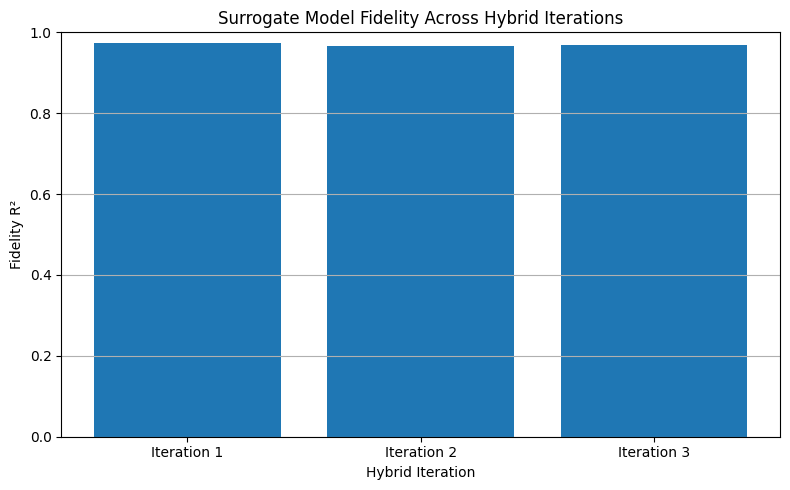

In [26]:
# ------------------------------------------------------------
# 3. Surrogate fidelity chart
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    surrogate_fidelity_df["Iteration"],
    surrogate_fidelity_df["Fidelity_R2"]
)

plt.title("Surrogate Model Fidelity Across Hybrid Iterations")
plt.xlabel("Hybrid Iteration")
plt.ylabel("Fidelity R²")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.tight_layout()

plt.savefig(
    f"{save_dir}/01_Surrogate_Fidelity_R2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

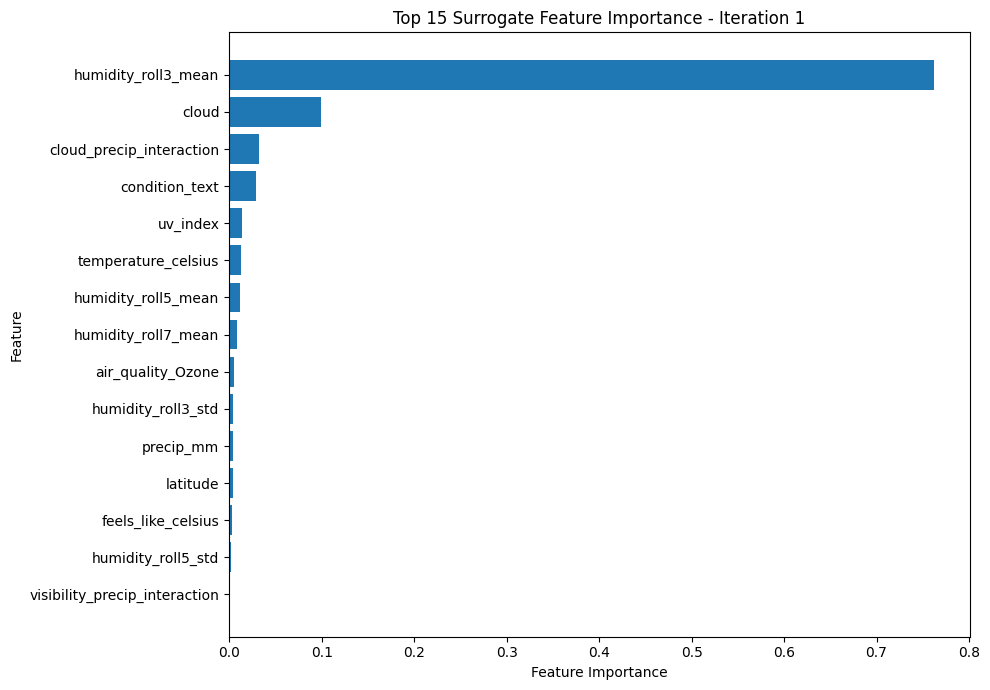

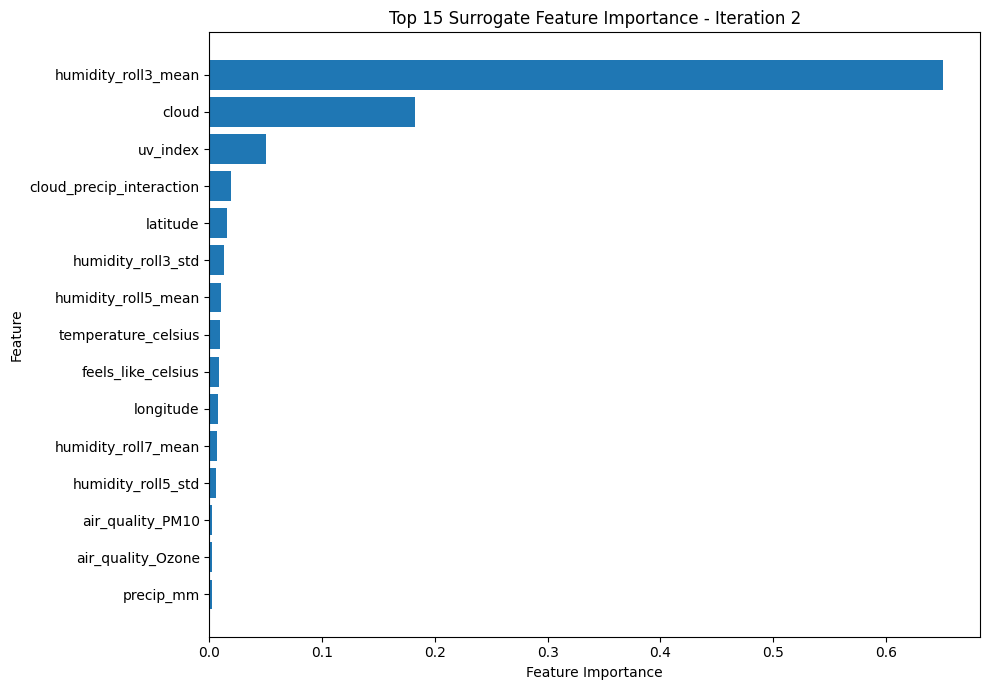

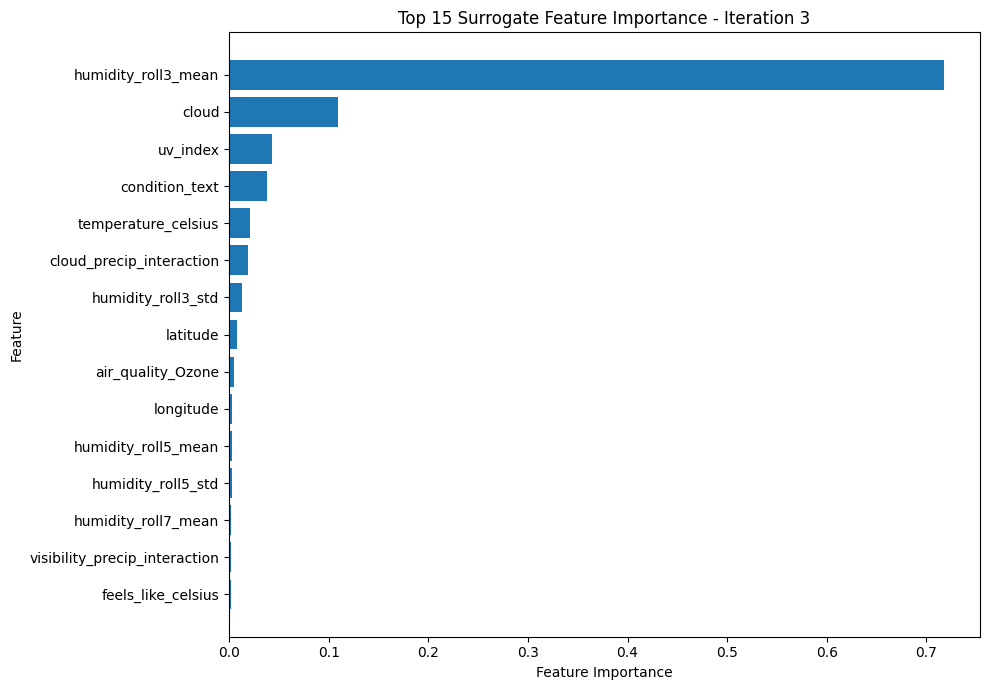

In [27]:
# ------------------------------------------------------------
# 4. Feature importance chart for each iteration
# ------------------------------------------------------------

for iteration_name in surrogate_data.keys():

    fi_iter = feature_importance_df[
        feature_importance_df["Iteration"] == iteration_name
    ].sort_values(by="Importance", ascending=False).head(15)

    plt.figure(figsize=(10, 7))

    plt.barh(
        fi_iter["Feature"][::-1],
        fi_iter["Importance"][::-1]
    )

    plt.title(f"Top 15 Surrogate Feature Importance - {iteration_name}")
    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")
    plt.tight_layout()

    plt.savefig(
        f"{save_dir}/02_Feature_Importance_{safe_name(iteration_name)}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

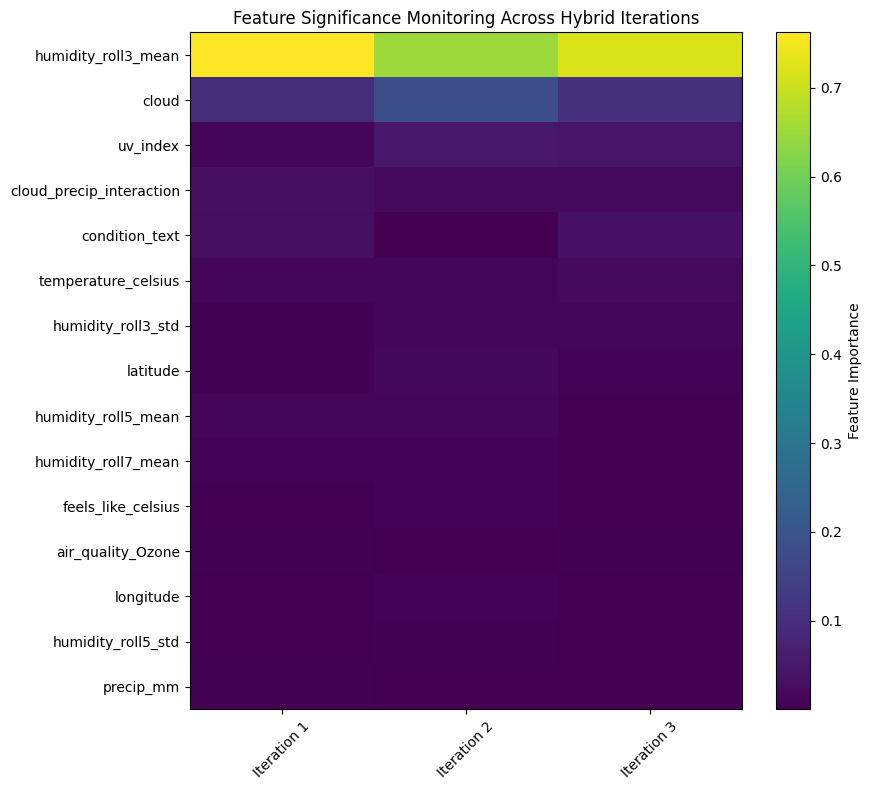

In [28]:
# ------------------------------------------------------------
# 5. Feature significance monitoring heatmap
# ------------------------------------------------------------

top_features = (
    feature_importance_df
    .groupby("Feature")["Importance"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .index
)

monitor_df = feature_importance_df[
    feature_importance_df["Feature"].isin(top_features)
].pivot(
    index="Feature",
    columns="Iteration",
    values="Importance"
).fillna(0)

monitor_df = monitor_df.loc[top_features]

monitor_df.to_csv(
    f"{save_dir}/Feature_Significance_Monitoring_Table.csv"
)

plt.figure(figsize=(9, 8))

plt.imshow(monitor_df.values, aspect="auto")

plt.xticks(
    ticks=np.arange(len(monitor_df.columns)),
    labels=monitor_df.columns,
    rotation=45
)

plt.yticks(
    ticks=np.arange(len(monitor_df.index)),
    labels=monitor_df.index
)

plt.colorbar(label="Feature Importance")
plt.title("Feature Significance Monitoring Across Hybrid Iterations")
plt.tight_layout()

plt.savefig(
    f"{save_dir}/03_Feature_Significance_Monitoring_Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

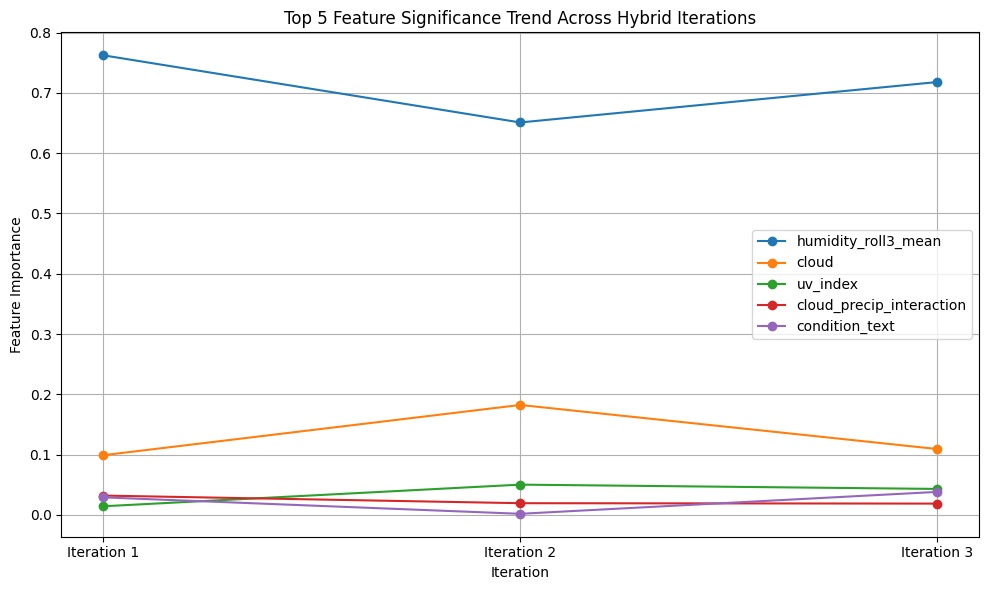

In [29]:
# ------------------------------------------------------------
# 6. Top 5 feature trend across iterations
# ------------------------------------------------------------

top5_features = (
    feature_importance_df
    .groupby("Feature")["Importance"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
)

trend_df = feature_importance_df[
    feature_importance_df["Feature"].isin(top5_features)
].pivot(
    index="Iteration",
    columns="Feature",
    values="Importance"
).fillna(0)

trend_df.to_csv(
    f"{save_dir}/Top5_Feature_Importance_Trend_Table.csv"
)

plt.figure(figsize=(10, 6))

for feature in top5_features:
    plt.plot(
        trend_df.index,
        trend_df[feature],
        marker="o",
        label=feature
    )

plt.title("Top 5 Feature Significance Trend Across Hybrid Iterations")
plt.xlabel("Iteration")
plt.ylabel("Feature Importance")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{save_dir}/04_Top5_Feature_Importance_Trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

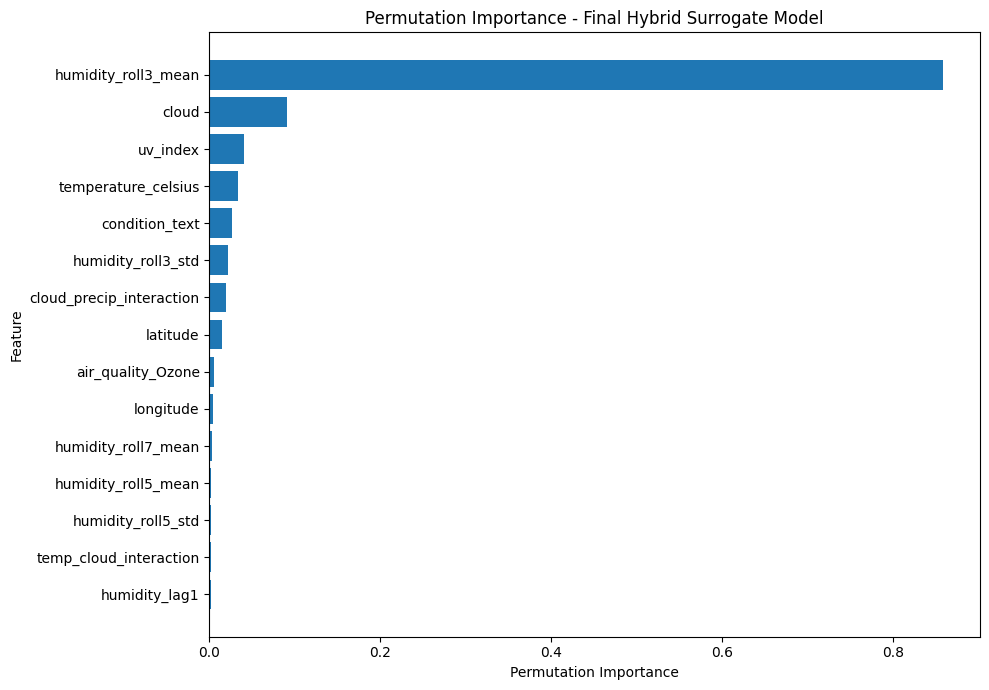

,Feature,Permutation_Importance
20,humidity_roll3_mean,0.858961
1,cloud,0.090999
0,uv_index,0.040716
4,temperature_celsius,0.033114
2,condition_text,0.026840
23,humidity_roll3_std,0.021621
40,cloud_precip_interaction,0.019873
14,latitude,0.015195
3,air_quality_Ozone,0.004855
8,longitude,0.003814


In [30]:
# ------------------------------------------------------------
# 7. Permutation importance for final surrogate model
# ------------------------------------------------------------

final_iteration = "Iteration 3"

final_surrogate = surrogate_models[final_iteration]["model"]
X_final = surrogate_models[final_iteration]["X_sample"]
y_final = surrogate_models[final_iteration]["y_sample"]

perm_result = permutation_importance(
    final_surrogate,
    X_final,
    y_final,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "Feature": X_final.columns,
    "Permutation_Importance": perm_result.importances_mean
}).sort_values(by="Permutation_Importance", ascending=False)

perm_df.to_csv(
    f"{save_dir}/Final_Iteration_Permutation_Importance.csv",
    index=False
)

top_perm = perm_df.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_perm["Feature"][::-1],
    top_perm["Permutation_Importance"][::-1]
)

plt.title("Permutation Importance - Final Hybrid Surrogate Model")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(
    f"{save_dir}/05_Final_Permutation_Importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

display(perm_df.head(20))

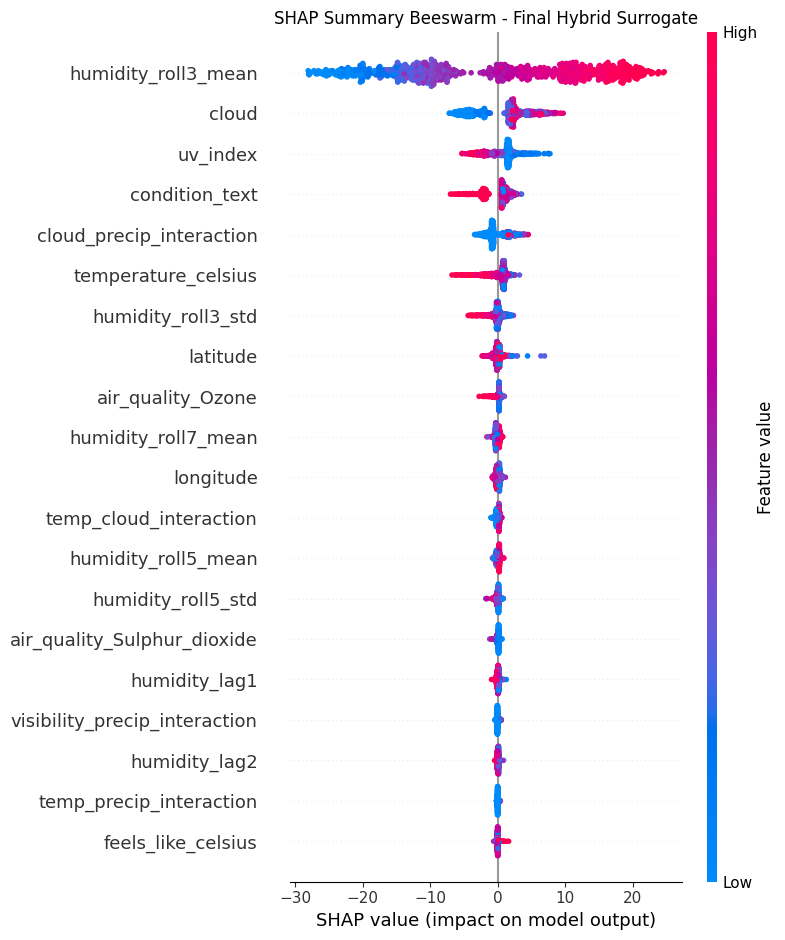

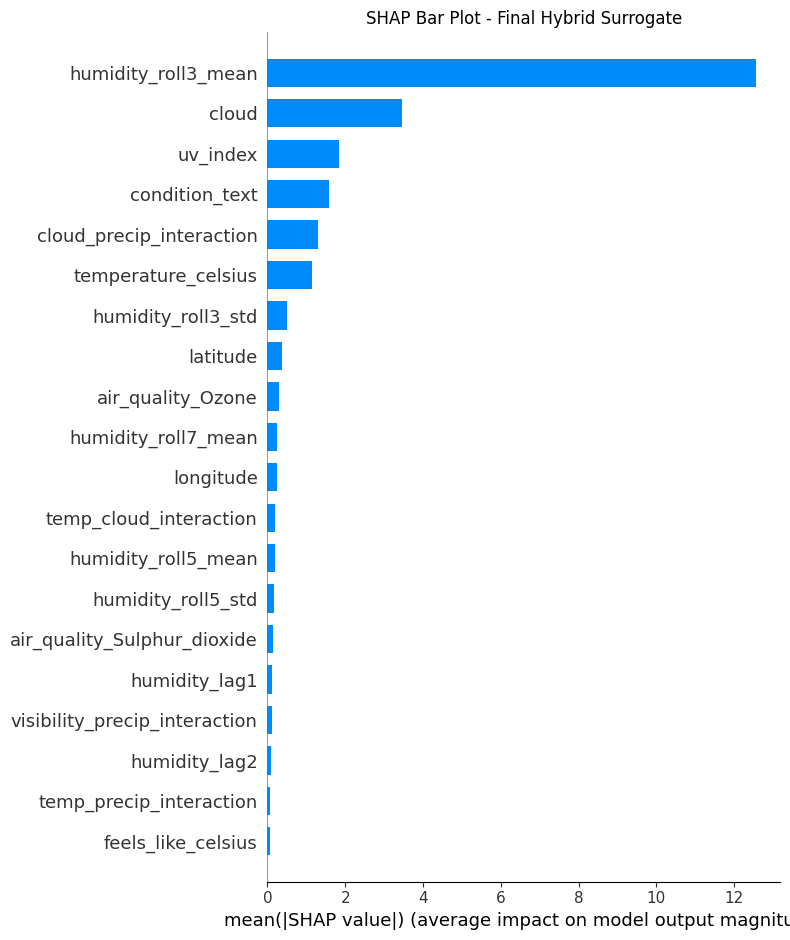

In [31]:
# ------------------------------------------------------------
# 8. SHAP explainability for final surrogate model
# ------------------------------------------------------------

X_shap = X_final.sample(
    min(1000, len(X_final)),
    random_state=42
)

explainer = shap.TreeExplainer(final_surrogate)

shap_values = explainer.shap_values(X_shap)

# SHAP Summary Beeswarm

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=X_shap.columns,
    show=False
)

plt.title("SHAP Summary Beeswarm - Final Hybrid Surrogate")
plt.tight_layout()

plt.savefig(
    f"{save_dir}/06_SHAP_Summary_Beeswarm_Final_Surrogate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# SHAP Bar Plot

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=X_shap.columns,
    plot_type="bar",
    show=False
)

plt.title("SHAP Bar Plot - Final Hybrid Surrogate")
plt.tight_layout()

plt.savefig(
    f"{save_dir}/07_SHAP_Bar_Final_Surrogate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

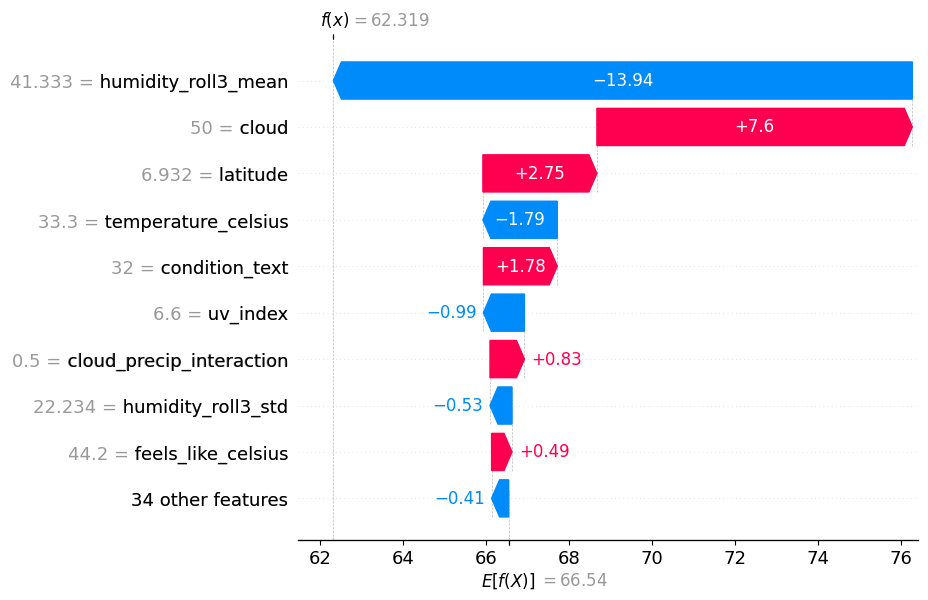

In [32]:
# ------------------------------------------------------------
# 9. SHAP waterfall plot
# ------------------------------------------------------------

sample_index = 0

explanation = shap.Explanation(
    values=shap_values[sample_index],
    base_values=explainer.expected_value,
    data=X_shap.iloc[sample_index],
    feature_names=X_shap.columns
)

shap.plots.waterfall(
    explanation,
    show=False
)

plt.savefig(
    f"{save_dir}/08_SHAP_Waterfall_Final_Surrogate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

Top 3 SHAP Features:
['humidity_roll3_mean', 'cloud', 'uv_index']


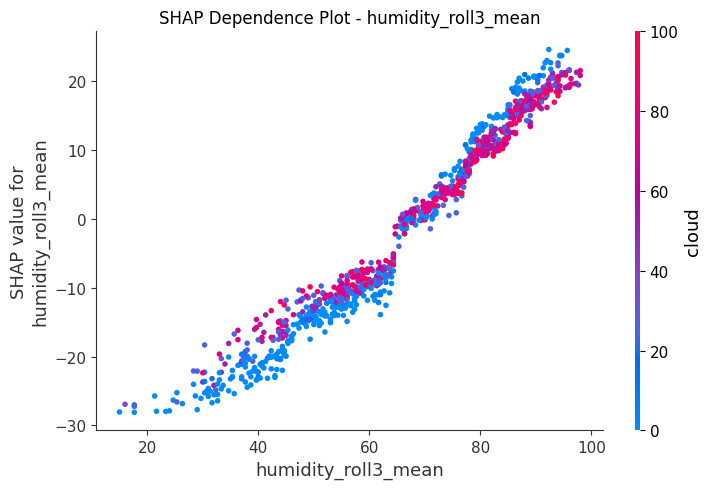

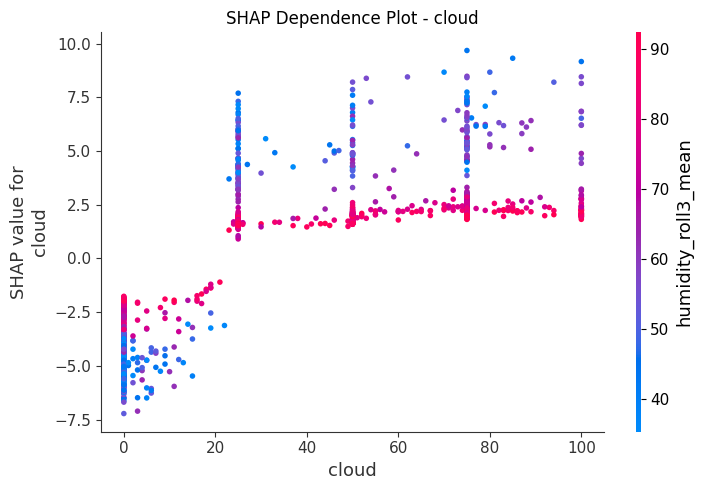

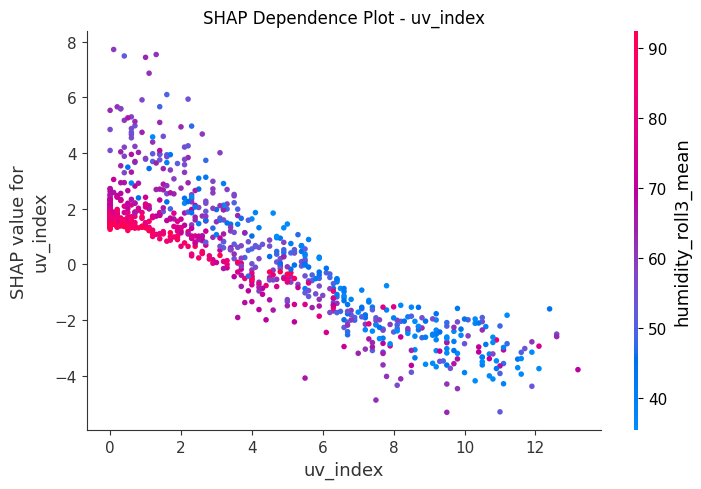

In [33]:
# ------------------------------------------------------------
# 10. SHAP dependence plots for top 3 features
# ------------------------------------------------------------

shap_importance = np.abs(shap_values).mean(axis=0)

top3_shap_features = X_shap.columns[
    np.argsort(shap_importance)[::-1][:3]
]

print("Top 3 SHAP Features:")
print(list(top3_shap_features))

for feature in top3_shap_features:

    shap.dependence_plot(
        feature,
        shap_values,
        X_shap,
        interaction_index="auto",
        show=False
    )

    plt.title(f"SHAP Dependence Plot - {feature}")
    plt.tight_layout()

    plt.savefig(
        f"{save_dir}/09_SHAP_Dependence_{safe_name(feature)}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

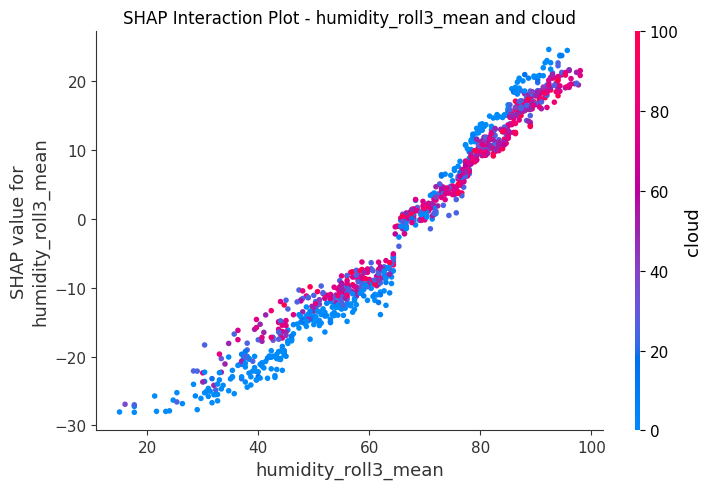

In [34]:
# ------------------------------------------------------------
# 11. SHAP interaction plot
# ------------------------------------------------------------

feature1 = top3_shap_features[0]
feature2 = top3_shap_features[1]

shap.dependence_plot(
    feature1,
    shap_values,
    X_shap,
    interaction_index=feature2,
    show=False
)

plt.title(f"SHAP Interaction Plot - {feature1} and {feature2}")
plt.tight_layout()

plt.savefig(
    f"{save_dir}/10_SHAP_Interaction_{safe_name(feature1)}_{safe_name(feature2)}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

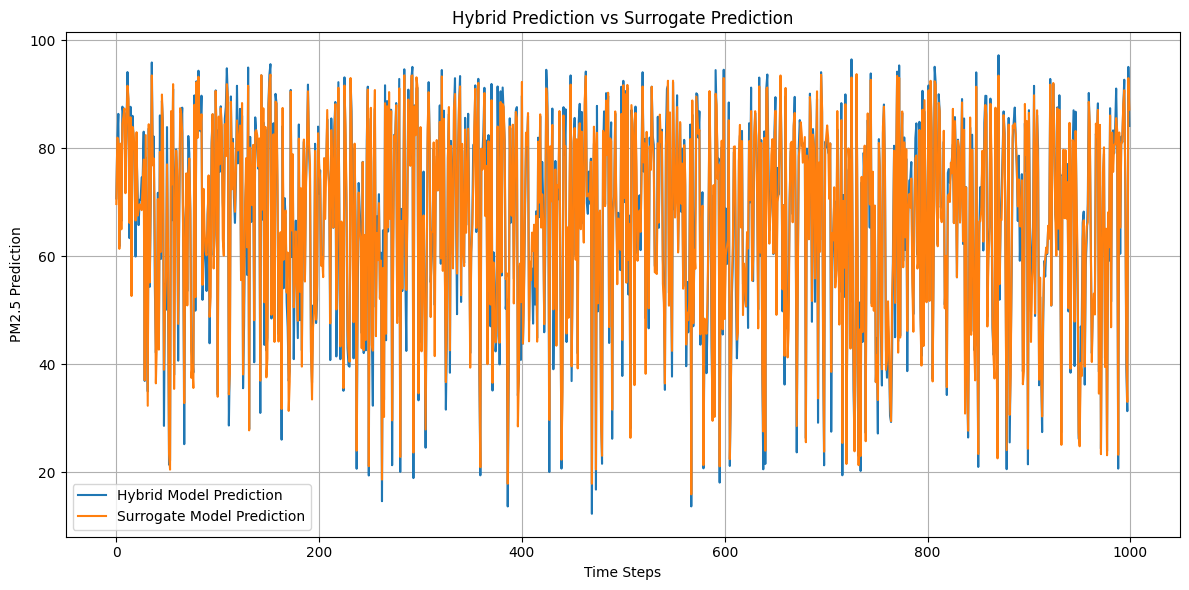

In [35]:
# ------------------------------------------------------------
# 12. Actual hybrid prediction vs surrogate prediction
# ------------------------------------------------------------

y_surrogate_pred = surrogate_models[final_iteration]["surrogate_pred"]

plot_n = min(1000, len(y_final))

plt.figure(figsize=(12, 6))

plt.plot(
    np.array(y_final[:plot_n]),
    label="Hybrid Model Prediction"
)

plt.plot(
    y_surrogate_pred[:plot_n],
    label="Surrogate Model Prediction"
)

plt.title("Hybrid Prediction vs Surrogate Prediction")
plt.xlabel("Time Steps")
plt.ylabel("PM2.5 Prediction")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{save_dir}/11_Hybrid_vs_Surrogate_Prediction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

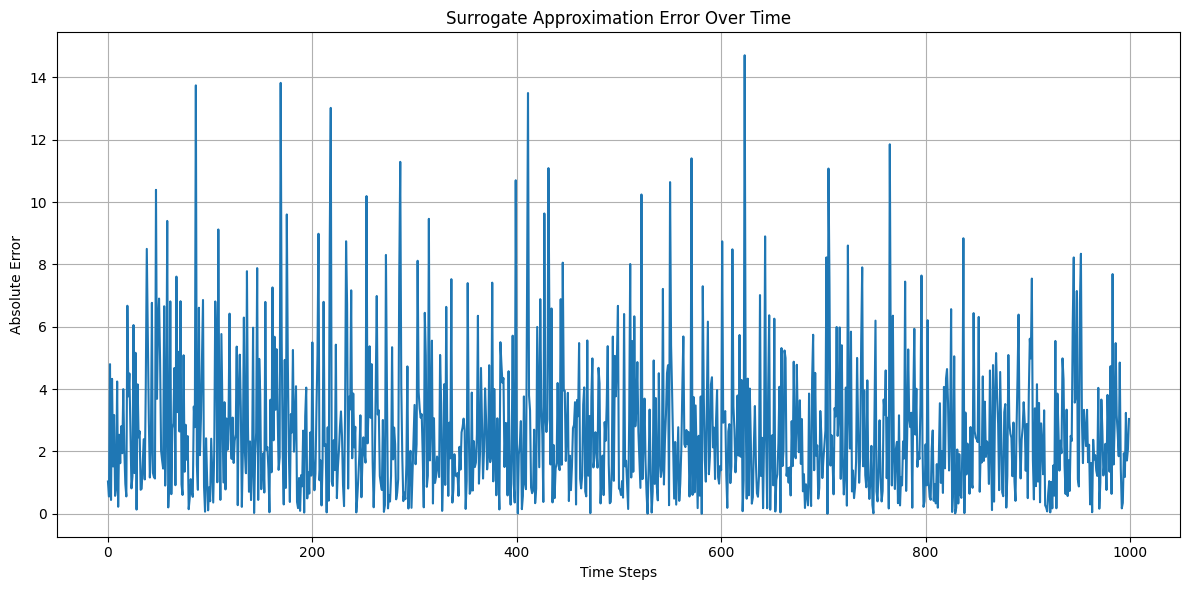

In [36]:
# ------------------------------------------------------------
# 13. Surrogate residual error plot
# ------------------------------------------------------------

surrogate_error = np.abs(np.array(y_final) - y_surrogate_pred)

plt.figure(figsize=(12, 6))

plt.plot(surrogate_error[:plot_n])

plt.title("Surrogate Approximation Error Over Time")
plt.xlabel("Time Steps")
plt.ylabel("Absolute Error")
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{save_dir}/12_Surrogate_Error_Over_Time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [37]:
# ------------------------------------------------------------
# 14. Download all outputs as ZIP
# ------------------------------------------------------------

zip_path = "/content/Hybrid_Surrogate_XAI_Outputs.zip"

with zipfile.ZipFile(zip_path, "w") as zipf:
    for root, dirs, files_list in os.walk(save_dir):
        for file in files_list:
            file_path = os.path.join(root, file)
            zipf.write(file_path, arcname=file)

files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>